## Transfer Learning and Fine-Tuning for Dog Classification

This notebook implements transfer learning and fine-tuning using pretrained ImageNet models to classify dog images into three classes:

- diego_dog
- lalo_dog
- stanford_dogs_subset (any other dog)

In [34]:
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import copy
import seaborn as sns
import pandas as pd
import time

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
from torch.optim import Adam
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

from sklearn.metrics import classification_report, confusion_matrix

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [36]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [37]:
data_dir = Path("./images")

class_names = ["diego_dog", "lalo_dog", "stanford_dogs_subset"]
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
num_classes = len(class_names)

In [38]:
image_extensions = {".jpg", ".jpeg", ".png"}

samples = []
class_counts = {}

for class_name in class_names:
    class_dir = data_dir / class_name
    if not class_dir.exists():
        raise FileNotFoundError(f"No se encontro la carpeta de la clase: {class_dir}")

    class_samples = []
    for img_path in class_dir.rglob("*"):
        if img_path.is_file() and img_path.suffix.lower() in image_extensions:
            class_samples.append((str(img_path), class_to_idx[class_name]))

    if len(class_samples) == 0:
        raise ValueError(f"La clase {class_name} no tiene imagenes validas.")

    samples.extend(class_samples)
    class_counts[class_name] = len(class_samples)

class_counts_df = pd.DataFrame({
    "class": list(class_counts.keys()),
    "count": list(class_counts.values())
})

display(class_counts_df)
print(f"Total samples: {len(samples)}")

,class,count
0,diego_dog,30
1,lalo_dog,30
2,stanford_dogs_subset,1200


Total samples: 1260


In [39]:
def split_dataset_by_class(samples, class_names, train_pct=0.8, val_pct=0.1, test_pct=0.1, seed=SEED):
    if not np.isclose(train_pct + val_pct + test_pct, 1.0):
        raise ValueError("train_pct, val_pct y test_pct deben sumar 1.0")

    rng = random.Random(seed)
    by_class = {idx: [] for idx in range(len(class_names))}

    for img_path, label in samples:
        by_class[label].append(img_path)

    split_items = {"train": [], "validation": [], "test": []}

    for label, class_paths in by_class.items():
        total_class_samples = len(class_paths)
        if total_class_samples < 3:
            raise ValueError(
                f"La clase {class_names[label]} necesita al menos 3 imagenes "
                "para aparecer en train, validation y test."
            )

        shuffled_paths = class_paths.copy()
        rng.shuffle(shuffled_paths)

        n_val = max(1, int(round(total_class_samples * val_pct)))
        n_test = max(1, int(round(total_class_samples * test_pct)))

        while n_val + n_test > total_class_samples - 1:
            if n_val >= n_test and n_val > 1:
                n_val -= 1
            elif n_test > 1:
                n_test -= 1
            else:
                raise ValueError(
                    f"No se pudo repartir la clase {class_names[label]} "
                    "manteniendo ejemplos en los tres conjuntos."
                )

        n_train = total_class_samples - n_val - n_test

        train_class_paths = shuffled_paths[:n_train]
        val_class_paths = shuffled_paths[n_train:n_train + n_val]
        test_class_paths = shuffled_paths[n_train + n_val:]

        split_items["train"].extend((img_path, label) for img_path in train_class_paths)
        split_items["validation"].extend((img_path, label) for img_path in val_class_paths)
        split_items["test"].extend((img_path, label) for img_path in test_class_paths)

    split_data = {}
    for split_name, items in split_items.items():
        rng.shuffle(items)
        paths, labels = zip(*items)
        split_data[split_name] = (list(paths), list(labels))

    return split_data


splits = split_dataset_by_class(samples, class_names)

train_paths, train_labels = splits["train"]
val_paths, val_labels = splits["validation"]
test_paths, test_labels = splits["test"]


def build_split_summary(split_labels, all_labels, class_names):
    class_totals = np.bincount(all_labels, minlength=len(class_names))
    rows = []

    for split_name, labels_for_split in split_labels.items():
        split_total = len(labels_for_split)
        counts = np.bincount(labels_for_split, minlength=len(class_names))

        for label_idx, class_name in enumerate(class_names):
            rows.append({
                "set": split_name,
                "class": class_name,
                "count": int(counts[label_idx]),
                "% del set": round((counts[label_idx] / split_total) * 100, 2),
                "% de la clase": round((counts[label_idx] / class_totals[label_idx]) * 100, 2)
            })

    return pd.DataFrame(rows)


split_summary = build_split_summary(
    {
        "train": train_labels,
        "validation": val_labels,
        "test": test_labels
    },
    [label for _, label in samples],
    class_names
)

assert (split_summary["count"] > 0).all(), "Cada clase debe aparecer al menos una vez en cada set."

display(split_summary)
print(f"Train: {len(train_paths)} | Validation: {len(val_paths)} | Test: {len(test_paths)}")

,set,class,count,% del set,% de la clase
0,train,diego_dog,24,2.38,80.0
1,train,lalo_dog,24,2.38,80.0
2,train,stanford_dogs_subset,960,95.24,80.0
3,validation,diego_dog,3,2.38,10.0
4,validation,lalo_dog,3,2.38,10.0
5,validation,stanford_dogs_subset,120,95.24,10.0
6,test,diego_dog,3,2.38,10.0
7,test,lalo_dog,3,2.38,10.0
8,test,stanford_dogs_subset,120,95.24,10.0


Train: 1008 | Validation: 126 | Test: 126


In [40]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

In [41]:
class DogDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [42]:
train_data = DogDataset(train_paths, train_labels, train_transform)
val_data = DogDataset(val_paths, val_labels, eval_transform)
test_data = DogDataset(test_paths, test_labels, eval_transform)

batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

## Funciones de entrenamiento

In [43]:
def train(model, train_loader, val_loader, criterion, optimizer, epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in tqdm(range(epochs), desc="Epochs"):
        model.train()
        train_loss = 0.0
        train_correct = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            pred = output.argmax(dim=1)
            train_correct += (pred == y).sum().item()

        train_loss = train_loss / len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_correct = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                output = model(x)
                loss = criterion(output, y)

                val_loss += loss.item() * x.size(0)
                pred = output.argmax(dim=1)
                val_correct += (pred == y).sum().item()

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        res['train_loss'].append(train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(val_loss)
        res['val_acc'].append(val_acc)

        tqdm.write(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}"
        )

    return res

## Graficar curvas


In [44]:
def plot_losses(res, title):
    plt.figure(figsize=(6, 4))
    plt.plot(res['train_loss'], label='train')
    plt.plot(res['val_loss'], label='validation')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def plot_accuracies(res, title):
    plt.figure(figsize=(6, 4))
    plt.plot(res['train_acc'], label='train')
    plt.plot(res['val_acc'], label='validation')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

## Model 1: ResNet18 Transfer Learning

Epochs:  10%|█         | 1/10 [00:13<02:03, 13.68s/it]

Epoch 1/10 | train_loss: 0.3791 | train_acc: 0.9058 | val_loss: 0.2152 | val_acc: 0.9524


Epochs:  20%|██        | 2/10 [00:26<01:46, 13.25s/it]

Epoch 2/10 | train_loss: 0.1896 | train_acc: 0.9524 | val_loss: 0.1360 | val_acc: 0.9524


Epochs:  30%|███       | 3/10 [00:40<01:33, 13.40s/it]

...

Epoch 8/10 | train_loss: 0.0485 | train_acc: 0.9792 | val_loss: 0.0416 | val_acc: 0.9921


Epochs:  90%|█████████ | 9/10 [02:00<00:12, 12.98s/it]

Epoch 9/10 | train_loss: 0.0472 | train_acc: 0.9851 | val_loss: 0.0307 | val_acc: 0.9841


Epochs: 100%|██████████| 10/10 [02:12<00:00, 13.26s/it]

Epoch 10/10 | train_loss: 0.0362 | train_acc: 0.9931 | val_loss: 0.0261 | val_acc: 1.0000


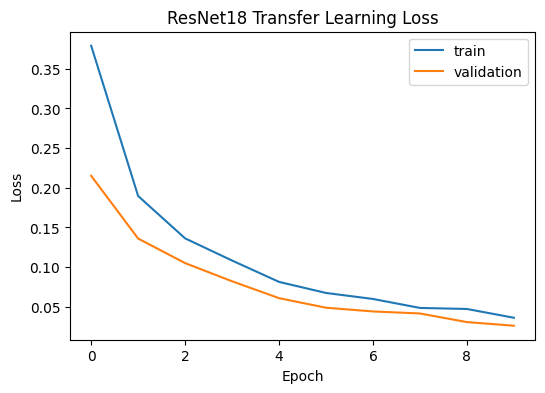

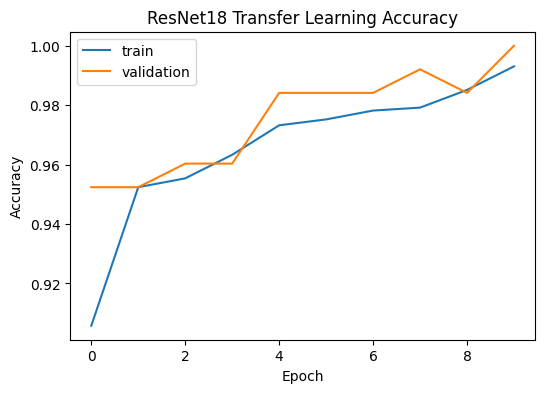

In [45]:
# Entrenar modelo resnet con transfer learning

weights = ResNet18_Weights.DEFAULT
model_resnet_tl = resnet18(weights=weights)

for param in model_resnet_tl.parameters():
    param.requires_grad = False

num_features = model_resnet_tl.fc.in_features
model_resnet_tl.fc = nn.Linear(num_features, num_classes)
model_resnet_tl = model_resnet_tl.to(device)

epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model_resnet_tl.fc.parameters(), lr=0.001)

resnet_tl_res = train(
    model_resnet_tl,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs
)

plot_losses(resnet_tl_res, 'ResNet18 Transfer Learning Loss')
plot_accuracies(resnet_tl_res, 'ResNet18 Transfer Learning Accuracy')

## Model 1: ResNet18 Fine-Tuning 

Epochs:  10%|█         | 1/10 [00:12<01:50, 12.30s/it]

Epoch 1/10 | train_loss: 0.0274 | train_acc: 0.9940 | val_loss: 0.0125 | val_acc: 1.0000


Epochs:  20%|██        | 2/10 [00:24<01:35, 12.00s/it]

Epoch 2/10 | train_loss: 0.0050 | train_acc: 1.0000 | val_loss: 0.0047 | val_acc: 1.0000


Epochs:  30%|███       | 3/10 [00:36<01:24, 12.08s/it]

...

Epoch 8/10 | train_loss: 0.0003 | train_acc: 1.0000 | val_loss: 0.0009 | val_acc: 1.0000


Epochs:  90%|█████████ | 9/10 [01:57<00:13, 13.71s/it]

Epoch 9/10 | train_loss: 0.0003 | train_acc: 1.0000 | val_loss: 0.0008 | val_acc: 1.0000


Epochs: 100%|██████████| 10/10 [02:10<00:00, 13.07s/it]

Epoch 10/10 | train_loss: 0.0003 | train_acc: 1.0000 | val_loss: 0.0007 | val_acc: 1.0000


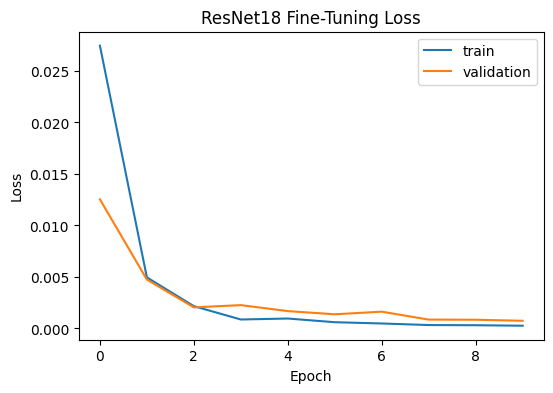

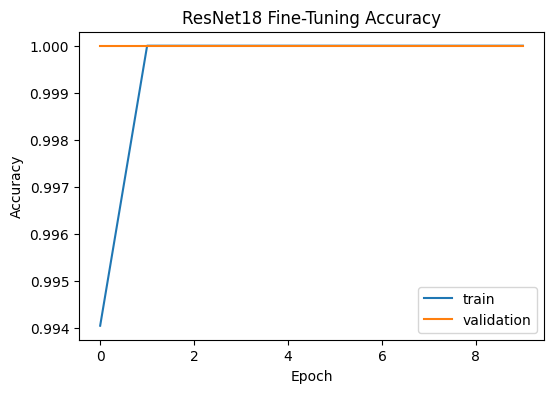

In [46]:
# Entrenar modelo resnet con fine tuning

model_resnet_ft = copy.deepcopy(model_resnet_tl)

for param in model_resnet_ft.parameters():
    param.requires_grad = False

for param in model_resnet_ft.layer4.parameters():
    param.requires_grad = True

for param in model_resnet_ft.fc.parameters():
    param.requires_grad = True

optimizer = Adam(
    filter(lambda p: p.requires_grad, model_resnet_ft.parameters()),
    lr=1e-4
)

resnet_ft_res = train(
    model_resnet_ft,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs
)

plot_losses(resnet_ft_res, 'ResNet18 Fine-Tuning Loss')
plot_accuracies(resnet_ft_res, 'ResNet18 Fine-Tuning Accuracy')

## Model 2: MobileNet Transfer Learning

Epochs:  10%|█         | 1/10 [00:12<01:56, 12.89s/it]

Epoch 1/10 | train_loss: 0.3119 | train_acc: 0.9415 | val_loss: 0.2018 | val_acc: 0.9524


Epochs:  20%|██        | 2/10 [00:25<01:42, 12.82s/it]

Epoch 2/10 | train_loss: 0.1748 | train_acc: 0.9524 | val_loss: 0.1328 | val_acc: 0.9603


Epochs:  30%|███       | 3/10 [00:39<01:32, 13.23s/it]

...

Epoch 8/10 | train_loss: 0.0388 | train_acc: 0.9921 | val_loss: 0.0259 | val_acc: 1.0000


Epochs:  90%|█████████ | 9/10 [01:57<00:13, 13.20s/it]

Epoch 9/10 | train_loss: 0.0337 | train_acc: 0.9960 | val_loss: 0.0241 | val_acc: 1.0000


Epochs: 100%|██████████| 10/10 [02:11<00:00, 13.12s/it]

Epoch 10/10 | train_loss: 0.0277 | train_acc: 0.9940 | val_loss: 0.0199 | val_acc: 1.0000


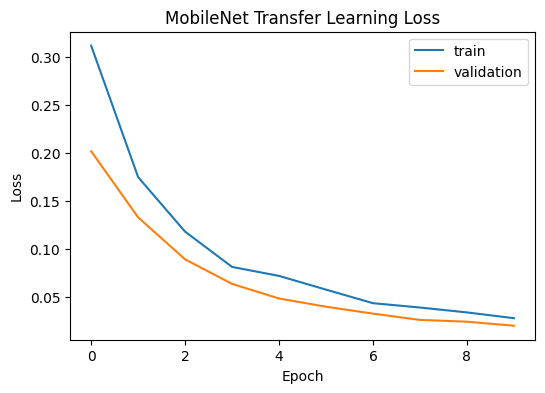

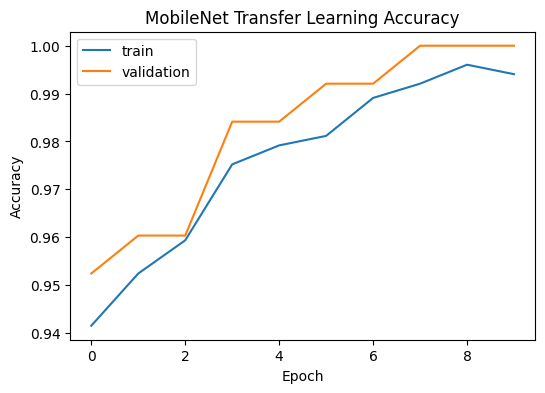

In [47]:
# Entrenar modelo mobilenet con transfer learning

weights = MobileNet_V2_Weights.DEFAULT
model_mobilenet_tl = mobilenet_v2(weights=weights)

for param in model_mobilenet_tl.parameters():
    param.requires_grad = False

num_features = model_mobilenet_tl.classifier[1].in_features
model_mobilenet_tl.classifier[1] = nn.Linear(num_features, num_classes)

model_mobilenet_tl = model_mobilenet_tl.to(device)

optimizer = Adam(model_mobilenet_tl.classifier.parameters(), lr=0.001)

mobilenet_tl_res = train(
    model_mobilenet_tl,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs
)

plot_losses(mobilenet_tl_res, 'MobileNet Transfer Learning Loss')
plot_accuracies(mobilenet_tl_res, 'MobileNet Transfer Learning Accuracy')

## Model 2: MobileNet Fine-Tuning

Epochs:  10%|█         | 1/10 [00:12<01:53, 12.61s/it]

Epoch 1/10 | train_loss: 0.0244 | train_acc: 0.9940 | val_loss: 0.0158 | val_acc: 1.0000


Epochs:  20%|██        | 2/10 [00:25<01:44, 13.05s/it]

Epoch 2/10 | train_loss: 0.0169 | train_acc: 0.9980 | val_loss: 0.0120 | val_acc: 1.0000


Epochs:  30%|███       | 3/10 [00:38<01:31, 13.02s/it]

...

Epoch 8/10 | train_loss: 0.0057 | train_acc: 1.0000 | val_loss: 0.0054 | val_acc: 1.0000


Epochs:  90%|█████████ | 9/10 [01:52<00:12, 12.21s/it]

Epoch 9/10 | train_loss: 0.0055 | train_acc: 1.0000 | val_loss: 0.0050 | val_acc: 1.0000


Epochs: 100%|██████████| 10/10 [02:04<00:00, 12.46s/it]

Epoch 10/10 | train_loss: 0.0046 | train_acc: 1.0000 | val_loss: 0.0046 | val_acc: 1.0000


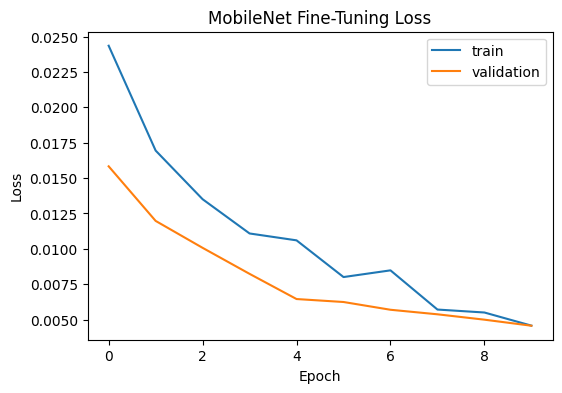

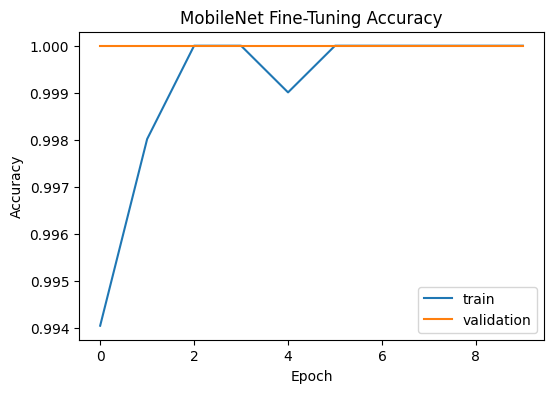

In [48]:
# Entrenar modelo mobilenet con fine tuning

model_mobilenet_ft = copy.deepcopy(model_mobilenet_tl)

for param in model_mobilenet_ft.parameters():
    param.requires_grad = False


for param in model_mobilenet_ft.features[-1].parameters():
    param.requires_grad = True

for param in model_mobilenet_ft.classifier.parameters():
    param.requires_grad = True

optimizer = Adam(
    filter(lambda p: p.requires_grad, model_mobilenet_ft.parameters()),
    lr=1e-4
)

mobilenet_ft_res = train(
    model_mobilenet_ft,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs
)

plot_losses(mobilenet_ft_res, 'MobileNet Fine-Tuning Loss')
plot_accuracies(mobilenet_ft_res, 'MobileNet Fine-Tuning Accuracy')

## Evaluacion y Comparacion

In [49]:
# Comparacion de los modelos en conjunto de validacion y eleccion del mejor modelo

def evaluate_model_validation(model, dataloader, criterion):
    model.eval()
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    start_time = time.time()
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            
            outputs = model(x)
            loss = criterion(outputs, y)
            
            total_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total_samples += x.size(0)
    
    end_time = time.time()
    
    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    inference_time = end_time - start_time
    
    return avg_loss, accuracy, inference_time


results_table = []

models_dict = {
    "ResNet18 TL": model_resnet_tl,
    "ResNet18 FT": model_resnet_ft,
    "MobileNet TL": model_mobilenet_tl,
    "MobileNet FT": model_mobilenet_ft,
}

for name, model in models_dict.items():
    val_loss, val_acc, inf_time = evaluate_model_validation(model, val_loader, criterion)
    
    results_table.append({
        "Model": name,
        "Val Loss": val_loss,
        "Val Accuracy": val_acc,
        "Inference Time (s)": inf_time
    })

df_results = pd.DataFrame(results_table).sort_values("Val Loss").reset_index(drop=True)

df_results

,Model,Val Loss,Val Accuracy,Inference Time (s)
0,ResNet18 FT,0.000743,1.0,1.326628
1,MobileNet FT,0.004565,1.0,1.224504
2,MobileNet TL,0.019851,1.0,1.287050
3,ResNet18 TL,0.026109,1.0,1.291404


Se elige como mejor modelo el que tenga la menor perdida en validacion, usando la tabla anterior.

In [50]:
best_model_name = df_results.loc[0, "Model"]
best_model = models_dict[best_model_name]

print(f"Mejor modelo segun validacion: {best_model_name}")

Mejor modelo segun validacion: ResNet18 FT


                      precision    recall  f1-score   support

           diego_dog       1.00      1.00      1.00         3
            lalo_dog       1.00      0.67      0.80         3
stanford_dogs_subset       0.99      1.00      1.00       120

            accuracy                           0.99       126
           macro avg       1.00      0.89      0.93       126
        weighted avg       0.99      0.99      0.99       126

Classes in y_true: [0 1 2]
Classes in y_pred: [0 1 2]


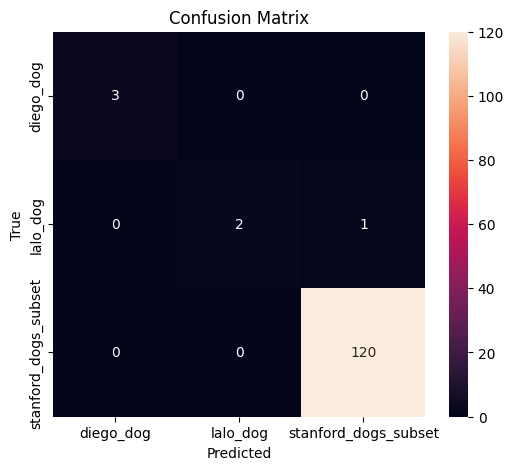

In [51]:
# Reporte del mejor modelo en conjunto de prueba 

def evaluate(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            output = model(x)

            preds = output.argmax(dim=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(y.numpy())

    return np.array(y_true), np.array(y_pred)


y_true, y_pred = evaluate(best_model, test_loader)
all_class_labels = list(range(len(class_names)))

print(classification_report(
    y_true,
    y_pred,
    labels=all_class_labels,
    target_names=class_names,
    zero_division=0
))

print("Classes in y_true:", np.unique(y_true))
print("Classes in y_pred:", np.unique(y_pred))

cm = confusion_matrix(y_true, y_pred, labels=all_class_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

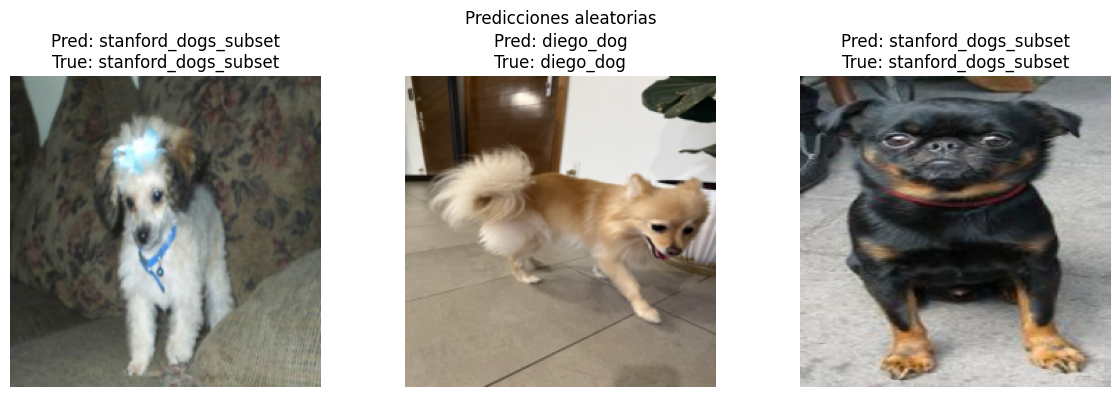

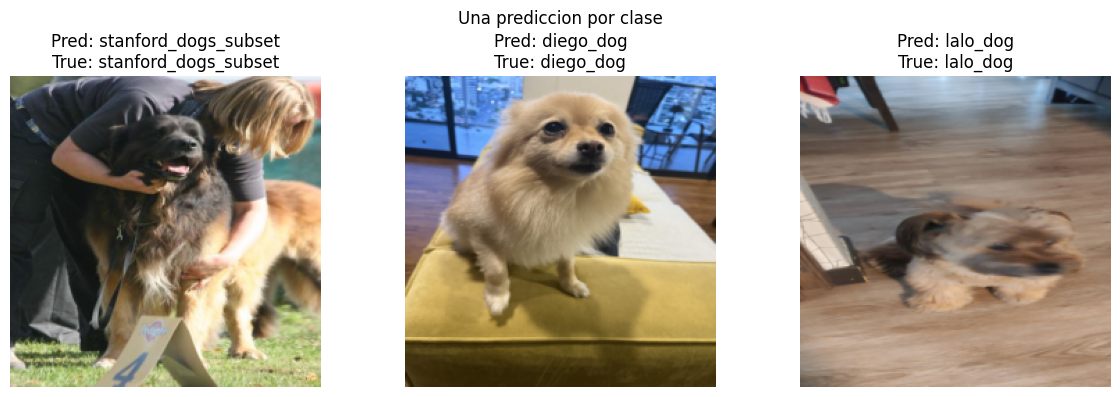

In [52]:
# Prueba del mejor modelo con imagenes aleatorias de prueba y una muestra por clase

def show_predictions_from_indices(model, dataset, class_names, indices, title):
    model.eval()
    num_samples = len(indices)
    
    plt.figure(figsize=(4 * num_samples, 4))
    plt.suptitle(title)
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        
        # desnormalizar para mostrar la imagen correctamente
        img_to_show = image.clone()
        img_to_show = img_to_show * std + mean
        img_to_show = torch.clamp(img_to_show, 0, 1)
        
        # prediccion
        with torch.no_grad():
            input_tensor = image.unsqueeze(0).to(device)
            output = model(input_tensor)
            pred = output.argmax(dim=1).item()
        
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img_to_show.permute(1, 2, 0).cpu().numpy())
        
        true_label = class_names[label]
        pred_label = class_names[pred]
        
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()


def show_random_predictions(model, dataset, class_names, num_samples=3):
    indices = random.sample(range(len(dataset)), num_samples)
    show_predictions_from_indices(model, dataset, class_names, indices, "Predicciones aleatorias")


def show_one_prediction_per_class(model, dataset, class_names):
    indices = []
    labels_found = set()
    
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        if label not in labels_found:
            indices.append(idx)
            labels_found.add(label)
        
        if len(labels_found) == len(class_names):
            break
    
    missing_classes = set(range(len(class_names))) - labels_found
    if missing_classes:
        missing_class_names = [class_names[label] for label in missing_classes]
        print(f"No se encontraron ejemplos en test para: {missing_class_names}")
    
    show_predictions_from_indices(model, dataset, class_names, indices, "Una prediccion por clase")


show_random_predictions(best_model, test_data, class_names)
show_one_prediction_per_class(best_model, test_data, class_names)

## Reflexion Personal Diego:

Realizar esta actividad me permitió entender mejor cómo aprovechar modelos preentrenados para desarrollar soluciones de deep learning de forma más rápida y eficiente. Con Transfer Learning se reutiliza un modelo ya entrenado y solo se adapta la capa final, mientras que con Fine-Tuning también se ajustan algunas capas internas para mejorar el desempeño en una tarea específica.

Durante la práctica se observó que los modelos con Fine-Tuning lograron mejores resultados, aunque esto también puede aumentar el riesgo de overfitting, especialmente cuando se trabaja con datasets pequeños. Además, quedó claro que la cantidad y distribución de los datos influyen mucho en el rendimiento del modelo.

En conclusión, ambas técnicas son muy útiles, ya que permiten obtener buenos resultados sin necesidad de entrenar una red neuronal desde cero.

## Reflexion Personal Eduardo:

Realizar esta tarea me permitió aprender a aprovechar modelos preentrenados para agilizar de gran manera la creación de un modelo para cierta tarea. El transfer learning se aprovecha todo el mode ya entrenado previamente y solo se reemplaza y entrena la capa de salida. Esto hace que al entrenar, sea mucho más rápido que entrenar todo un modelo completo desde cero. Por otro lado, el Fine-Tuning consiste en tomar como base un modelo con Transfer Learning y aplicar el mismo entrenamiento que se aplicó con este método, solo que esta vez se activan algunas de las capas finales del modelo preentenado, entrenando así estas últimas capas y la nueva capa final. Al comparar los modelos generados en esta actividad, nos dimos cuenta de que aquellos que usaron Fine-Tuning tuvieron mejores resultados que los que tienen solo Transfer Learning. A pesar de esto, ambos tipos de modelos tuvieron resultados bastante aceptables. Creo que esta diferencia de desempeño entre modelos con Transfer learning y Fine-Tuning es un poco injusta ya que los modelos con Fine-Tuning usa como base los modelos Transfer Learning, por lo que ya tienen el aprednizaje de estos. Debido a esto es injusto decir que uno es mejor que otro. En mi caso prefiero verlo como que uno es una mejora del otro. Sin embargo, cabe aclarar que considero que aplicar Fine Tuning puede causar overfitting, por lo que no siempre será mejor que Transfer Learning. En el caso de esta actividad, no fue posible apreciar esto tan claro ya que el dataset personalizado fue demasiado pequeño. De hecho esto también causó algunos problemas en la particion de los datos, pues nos pasó que una clase no estaba presente en el conjunto de prueba. A pesar de esto, la actividad formó las bases para aplicar estas técnicas, las cuales pueden hacer que el desarrollo de un modelo sea mucho más rápido y sin necesidad de reinventar la rueda.